In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
import sys
import os

# Add parent directory to Python path
sys.path.insert(0, os.path.abspath('..'))

# Import FEM modules
from fem.core import Node, Material
from fem.sections import Membrane
from fem.elements import CST, LST, Quad4
from fem.elements.quad9_1 import Quad9
from fem.utils import get_line_load_global_vector

from fem.utils import add_element_data_view, add_node_data_view, compute_nodal_average
from fem.utils.functions import build_nodes_from_gmsh, create_elements_from_gmsh, build_line_load_vector


# Import standard libraries
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math

In [3]:
# Material and section — same as before
Steel = Material(name='Steel', E=200000.0, nu=0.30, rho=0.0)
SteelPlate = Membrane(name='SteelPlate', thickness=10, material=Steel)


In [4]:
# Nodes
n1 = Node(name=0, coordinates=[0,    0])
n2 = Node(name=1, coordinates=[1000, 0])
n3 = Node(name=2, coordinates=[1000, 1000])
n4 = Node(name=3, coordinates=[0,    1000])


In [5]:
# Boundary conditions — left side fixed
n1.set_restrain(['r', 'r'])
n4.set_restrain(['r', 'r'])

In [6]:
node_map = {1: n1, 2: n2, 3: n3, 4: n4}
nodes    = np.array([n1, n2, n3, n4], dtype=object)
nodeList = nodes

In [7]:
# Elements
elem1 = CST(element_tag=1, 
            node_list=[n1, n2, n3], 
            section=SteelPlate)

elem2 = CST(element_tag=2, 
            node_list=[n1, n3, n4], 
            section=SteelPlate)
elements    = np.array([elem1, elem2], dtype=object)
elementList = elements


In [8]:
for elem in elements:
    elem.printSummary()

-------------------------------------------------------------
CST Element 1
Type: planeStress
Nodes: [0, 1, 2]
  Node 0: (0.000, 0.000)
  Node 1: (1000.000, 0.000)
  Node 2: (1000.000, 1000.000)
Thickness: 10
Area: 500000.0000
Element DoF indices: [0 1 2 3 4 5]
Body force direction: None

Stiffness matrix (local):
[[ 1098901.098901        0.       -1098901.098901   329670.32967         0.        -329670.32967 ]
 [       0.         384615.384615   384615.384615  -384615.384615  -384615.384615        0.      ]
 [-1098901.098901   384615.384615  1483516.483516  -714285.714286  -384615.384615   329670.32967 ]
 [  329670.32967   -384615.384615  -714285.714286  1483516.483516   384615.384615 -1098901.098901]
 [       0.        -384615.384615  -384615.384615   384615.384615   384615.384615        0.      ]
 [ -329670.32967         0.         329670.32967  -1098901.098901        0.        1098901.098901]]
-------------------------------------------------------------

--------------------------

In [9]:
def plot_mesh(figsize=(25, 25),
              nodes=None, 
              elements=None,                
              show_node_labels=True, 
              show_element_labels=True):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot nodes if provided
    if nodes is not None:
        for node in nodes:
            node.plotGeometry(ax=ax, text=show_node_labels)
    # Plot elements if provided
    if elements is not None:
        for element in elements:
            element.plotGeometry(ax=ax)
            if show_element_labels:
                x, y = element.get_centroid()
                ax.text(x, y, f'{element.element_tag}', color='r', ha='center', fontsize=8)
    # Maintain 1:1 aspect ratio
    ax.set_aspect('equal')
    plt.show()

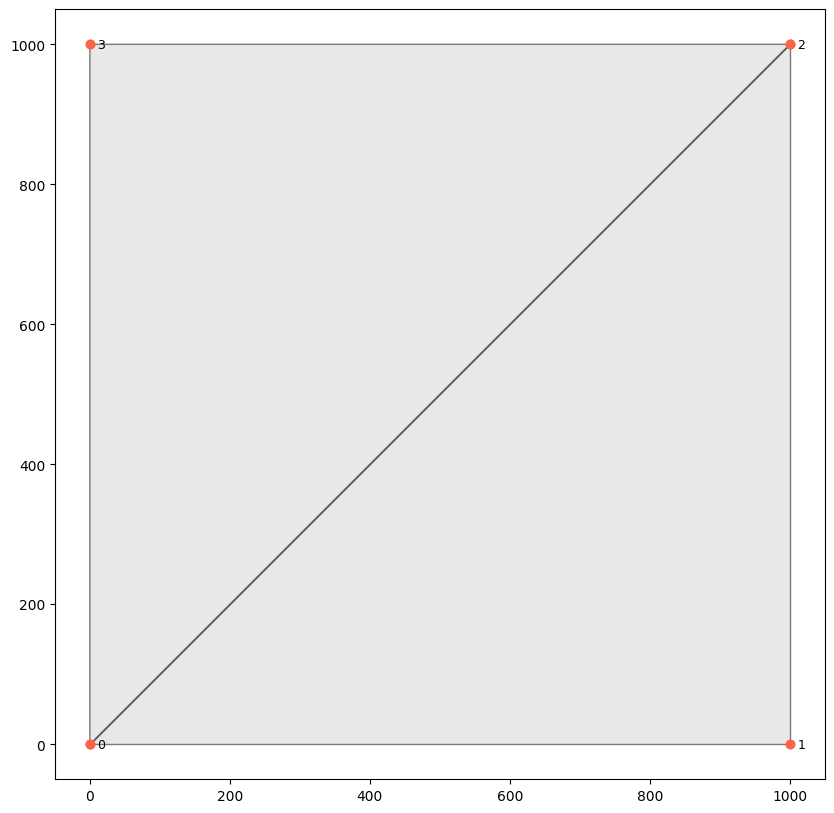

In [10]:
# Plot
plot_mesh(figsize=(10, 10) , 
          nodes=nodes,
            elements=elements, 
            show_node_labels=True, 
            show_element_labels=False)

In [11]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = 2 * nNodes

In [12]:
F_line = np.zeros(system_nDof)

In [13]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodeList:
    F[node.idx] += node.nodalLoad
F += F_line

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodeList])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [14]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [15]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 2 at [1000. 1000.]:  ux=+0.000000  uy=+0.000000
Node 1 at [1000.    0.]:  ux=+0.000000  uy=+0.000000


In [16]:
# Reactions per node
for node in nodeList:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 0:  Rx=+0.000000  Ry=+0.000000
Node 3:  Rx=+0.000000  Ry=+0.000000
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: +0.0000   Balance: 0.0000e+00
Applied Y:  +0.0000   Reaction Y: +0.0000   Balance: 0.0000e+00
